In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

np.random.seed(42)

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
df = pd.read_csv('../data/processed/cleaned_transactions.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Dataset loaded: {len(df):,} rows × {len(df.columns)} columns")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"Total revenue: £{df['Revenue'].sum():,.2f}")

df.head()

Dataset loaded: 400,916 rows × 9 columns
Date range: 2009-12-01 07:45:00 to 2010-12-09 20:01:00
Total revenue: £8,798,233.74


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom,30.00


In [3]:
print("Dataset Overview\n")

print(f"Total Transactions: {len(df):,}")
print(f"Unique Customers: {df['Customer ID'].nunique():,}")
print(f"Unique Products: {df['StockCode'].nunique():,}")
print(f"Unique Countries: {df['Country'].nunique():,}")
print(f"Date Range: {(df['InvoiceDate'].max() - df['InvoiceDate'].min()).days} days")
print(f"\nTotal Revenue: £{df['Revenue'].sum():,.2f}")
print(f"Average Transaction Value: £{df['Revenue'].mean():.2f}")
print(f"Median Transaction Value: £{df['Revenue'].median():.2f}")

df.info()

Dataset Overview

Total Transactions: 400,916
Unique Customers: 4,312
Unique Products: 4,017
Unique Countries: 37
Date Range: 373 days

Total Revenue: £8,798,233.74
Average Transaction Value: £21.95
Median Transaction Value: £12.50
<class 'pandas.DataFrame'>
RangeIndex: 400916 entries, 0 to 400915
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      400916 non-null  int64         
 1   StockCode    400916 non-null  str           
 2   Description  400916 non-null  str           
 3   Quantity     400916 non-null  int64         
 4   InvoiceDate  400916 non-null  datetime64[us]
 5   Price        400916 non-null  float64       
 6   Customer ID  400916 non-null  float64       
 7   Country      400916 non-null  str           
 8   Revenue      400916 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(2), str(3)
memory usage: 44.8 MB


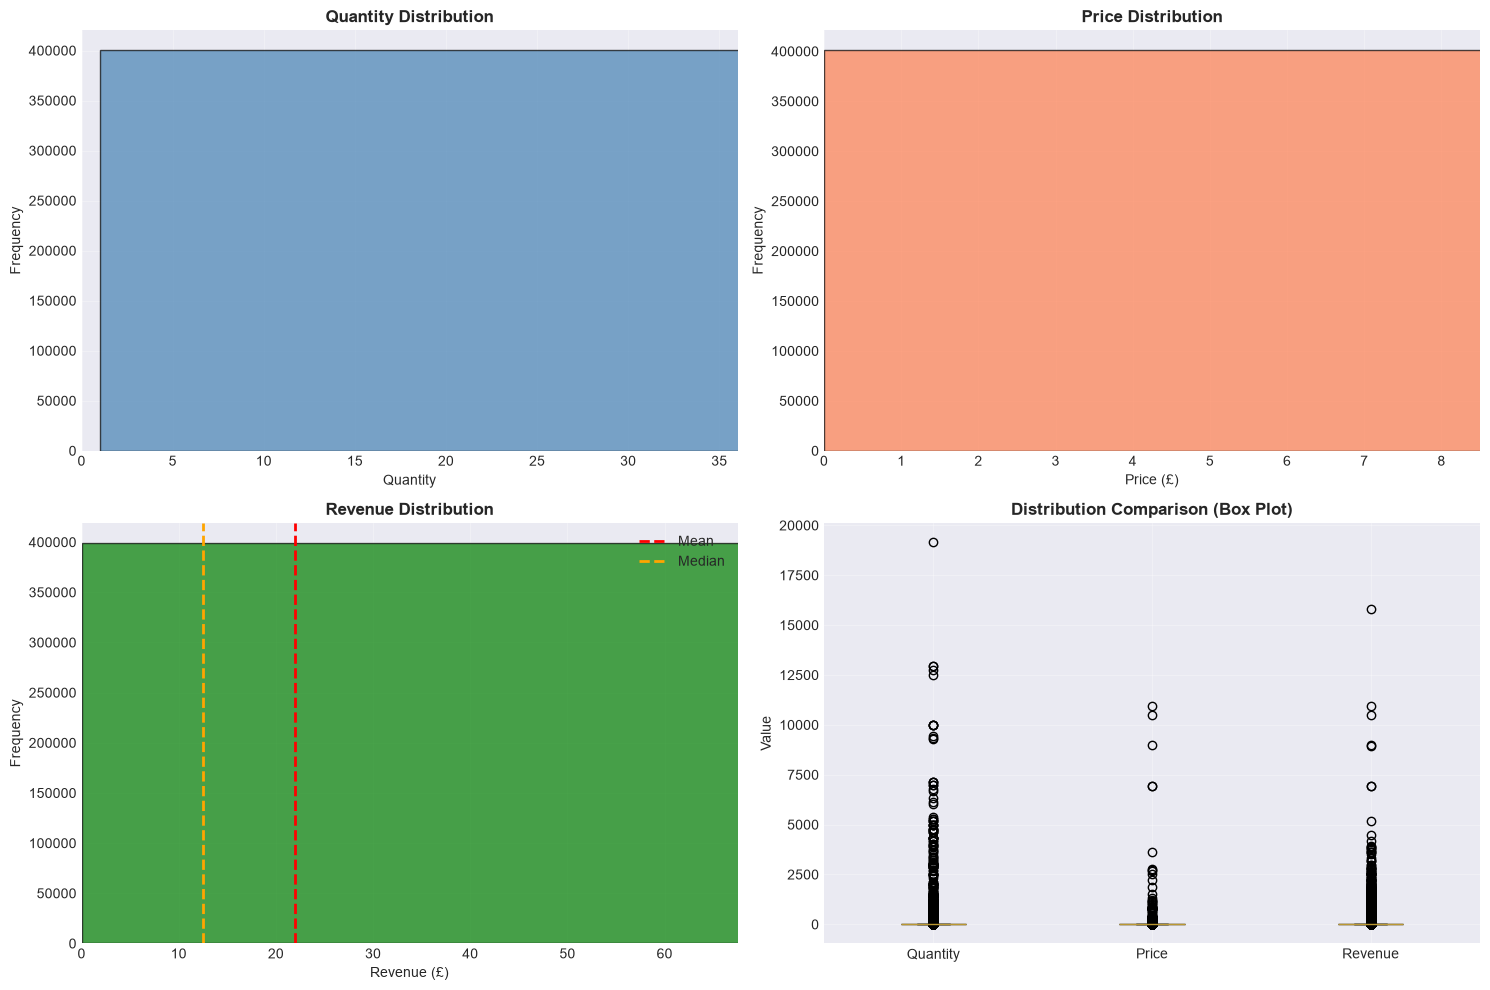

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(df['Quantity'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Quantity')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Quantity Distribution', fontweight='bold')
axes[0, 0].set_xlim(0, df['Quantity'].quantile(0.95))
axes[0, 0].grid(alpha=0.3)

axes[0, 1].hist(df['Price'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Price (£)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Price Distribution', fontweight='bold')
axes[0, 1].set_xlim(0, df['Price'].quantile(0.95))
axes[0, 1].grid(alpha=0.3)

axes[1, 0].hist(df['Revenue'], bins=50, color='green', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Revenue (£)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Revenue Distribution', fontweight='bold')
axes[1, 0].set_xlim(0, df['Revenue'].quantile(0.95))
axes[1, 0].axvline(df['Revenue'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 0].axvline(df['Revenue'].median(), color='orange', linestyle='--', linewidth=2, label='Median')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

boxplot_data = [df['Quantity'], df['Price'], df['Revenue']]
bp = axes[1, 1].boxplot(boxplot_data, patch_artist=True)
axes[1, 1].set_xticklabels(['Quantity', 'Price', 'Revenue'])
axes[1, 1].set_ylabel('Value')
axes[1, 1].set_title('Distribution Comparison (Box Plot)', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

for patch in bp['boxes']:
    patch.set_facecolor('lightblue')

plt.tight_layout()
plt.savefig('../reports/figures/eda_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
print("Statistical Summary\n")

stats_df = pd.DataFrame({
    'Metric': ['Count', 'Mean', 'Std', 'Min', '25%', '50%', '75%', 'Max'],
    'Quantity': [
        len(df), df['Quantity'].mean(), df['Quantity'].std(), 
        df['Quantity'].min(), df['Quantity'].quantile(0.25),
        df['Quantity'].median(), df['Quantity'].quantile(0.75), df['Quantity'].max()
    ],
    'Price': [
        len(df), df['Price'].mean(), df['Price'].std(),
        df['Price'].min(), df['Price'].quantile(0.25),
        df['Price'].median(), df['Price'].quantile(0.75), df['Price'].max()
    ],
    'Revenue': [
        len(df), df['Revenue'].mean(), df['Revenue'].std(),
        df['Revenue'].min(), df['Revenue'].quantile(0.25),
        df['Revenue'].median(), df['Revenue'].quantile(0.75), df['Revenue'].max()
    ]
})

stats_df

Statistical Summary



,Metric,Quantity,Price,Revenue
0,Count,400916.00,400916.00,400916.00
1,Mean,13.77,3.31,21.95
2,Std,97.64,35.05,77.76
3,Min,1.00,0.00,0.00
4,25%,2.00,1.25,5.00
5,50%,5.00,1.95,12.50
6,75%,12.00,3.75,19.50
7,Max,19152.00,10953.50,15818.40


In [7]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
df['Day'] = df['InvoiceDate'].dt.day
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

print("Temporal features created")
print(f"Years covered: {df['Year'].unique()}")
print(f"Months covered: {df['YearMonth'].nunique()}")

Temporal features created
Years covered: [2009 2010]
Months covered: 13


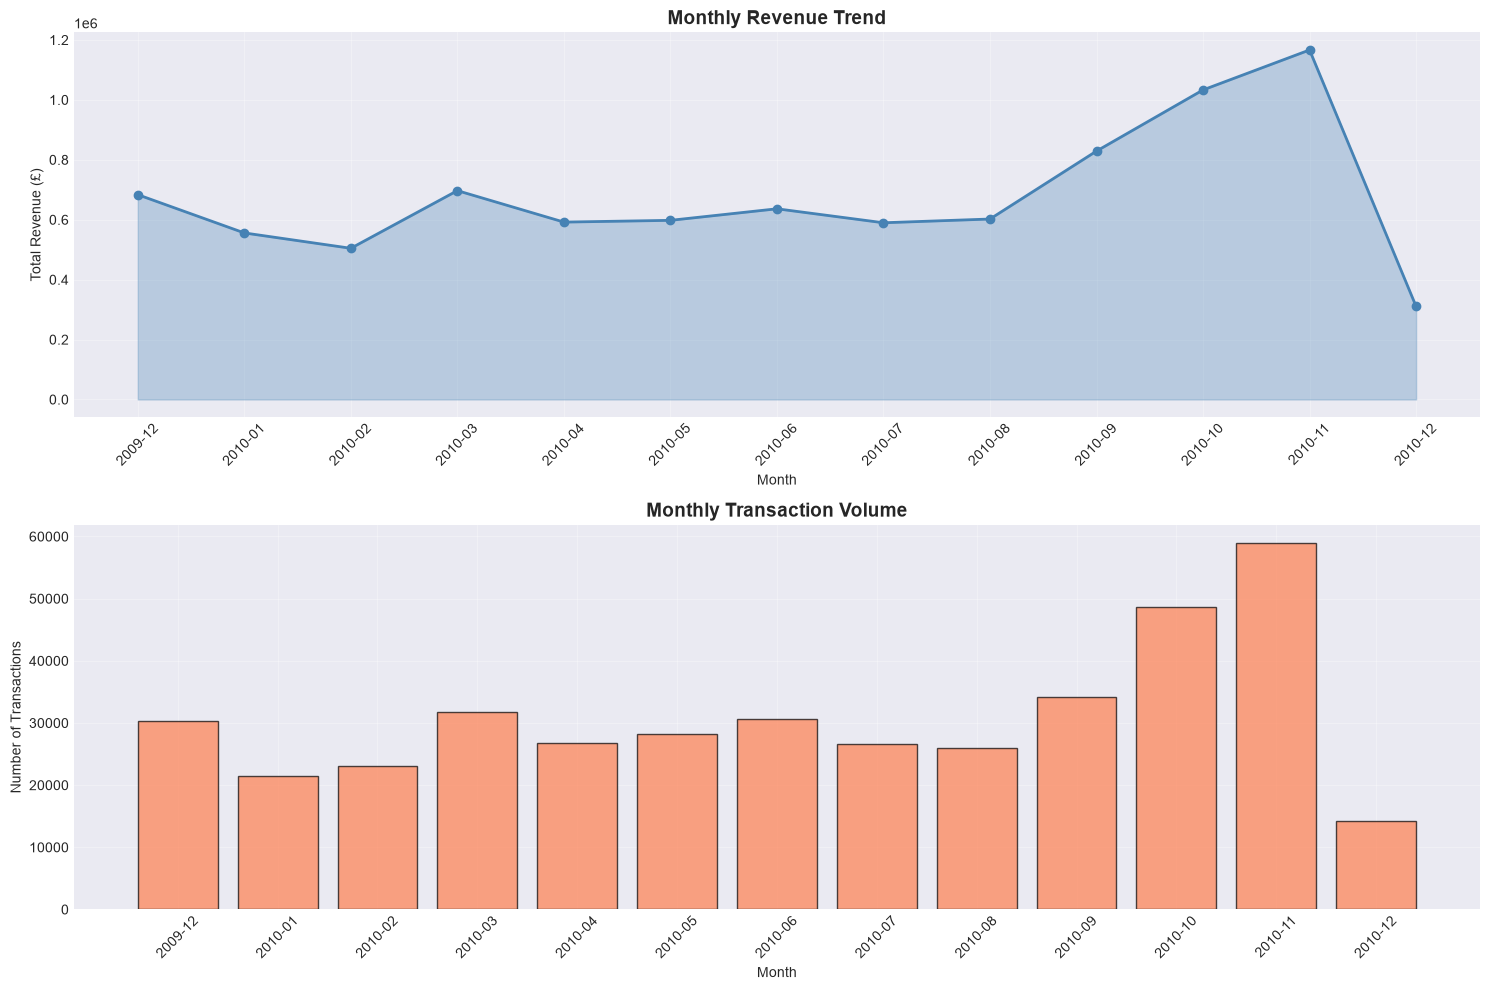


Highest revenue month: 2010-11
Revenue: £1,166,460.02


In [8]:
monthly_revenue = df.groupby('YearMonth')['Revenue'].agg(['sum', 'count', 'mean']).reset_index()
monthly_revenue.columns = ['YearMonth', 'Total_Revenue', 'Transactions', 'Avg_Revenue']
monthly_revenue['YearMonth'] = monthly_revenue['YearMonth'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

axes[0].plot(monthly_revenue['YearMonth'], monthly_revenue['Total_Revenue'], 
             marker='o', linewidth=2, markersize=6, color='steelblue')
axes[0].fill_between(range(len(monthly_revenue)), monthly_revenue['Total_Revenue'], 
                      alpha=0.3, color='steelblue')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Revenue (£)')
axes[0].set_title('Monthly Revenue Trend', fontweight='bold', fontsize=14)
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(monthly_revenue['YearMonth'], monthly_revenue['Transactions'], 
            color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Transactions')
axes[1].set_title('Monthly Transaction Volume', fontweight='bold', fontsize=14)
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/eda_time_trends.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nHighest revenue month: {monthly_revenue.loc[monthly_revenue['Total_Revenue'].idxmax(), 'YearMonth']}")
print(f"Revenue: £{monthly_revenue['Total_Revenue'].max():,.2f}")

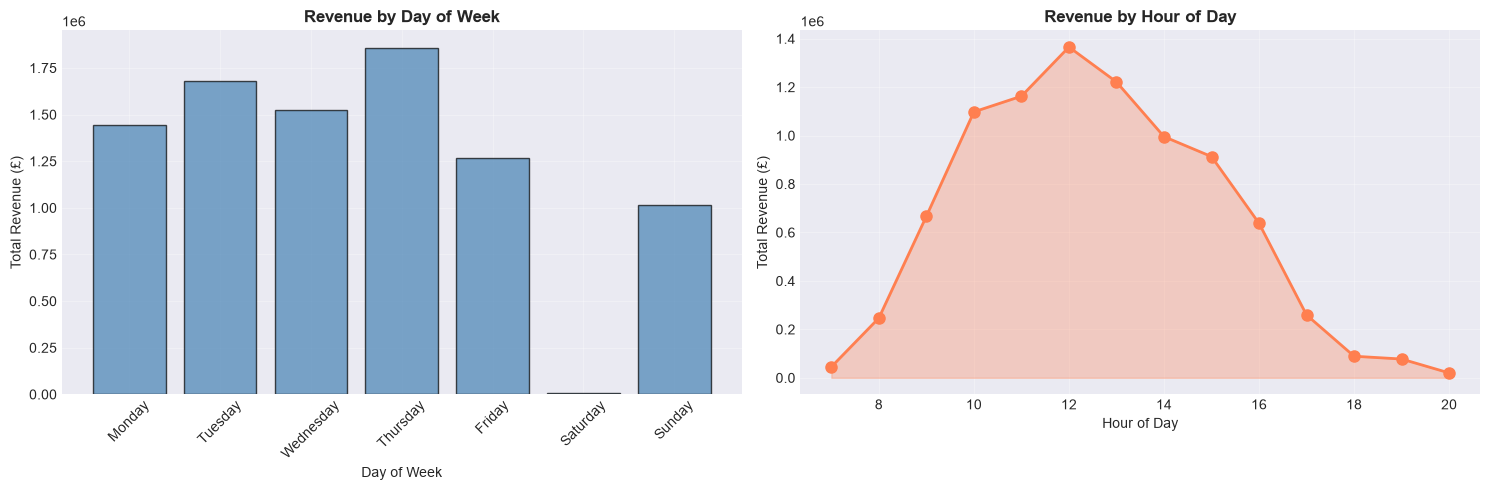

In [9]:
daily_pattern = df.groupby('DayOfWeek')['Revenue'].agg(['sum', 'count', 'mean']).reset_index()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_pattern['DayOfWeek'] = pd.Categorical(daily_pattern['DayOfWeek'], categories=day_order, ordered=True)
daily_pattern = daily_pattern.sort_values('DayOfWeek')

hourly_pattern = df.groupby('Hour')['Revenue'].agg(['sum', 'count', 'mean']).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(daily_pattern['DayOfWeek'], daily_pattern['sum'], 
            color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Total Revenue (£)')
axes[0].set_title('Revenue by Day of Week', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3)

axes[1].plot(hourly_pattern['Hour'], hourly_pattern['sum'], 
             marker='o', linewidth=2, markersize=8, color='coral')
axes[1].fill_between(hourly_pattern['Hour'], hourly_pattern['sum'], alpha=0.3, color='coral')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Total Revenue (£)')
axes[1].set_title('Revenue by Hour of Day', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/eda_temporal_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
customer_stats = df.groupby('Customer ID').agg({
    'Invoice': 'nunique',
    'Revenue': 'sum',
    'Quantity': 'sum',
    'InvoiceDate': ['min', 'max']
}).reset_index()

customer_stats.columns = ['Customer ID', 'Total_Orders', 'Total_Revenue', 
                          'Total_Items', 'First_Purchase', 'Last_Purchase']

customer_stats['Avg_Order_Value'] = customer_stats['Total_Revenue'] / customer_stats['Total_Orders']
customer_stats['Customer_Lifespan'] = (customer_stats['Last_Purchase'] - customer_stats['First_Purchase']).dt.days

print(f"Total Customers: {len(customer_stats):,}\n")
print("Customer Statistics:")
print(customer_stats[['Total_Orders', 'Total_Revenue', 'Avg_Order_Value']].describe())

Total Customers: 4,312

Customer Statistics:
       Total_Orders  Total_Revenue  Avg_Order_Value
count       4312.00        4312.00          4312.00
mean           4.46        2040.41           376.37
std            8.17        8911.76           492.36
min            1.00           2.95             2.95
25%            1.00         307.19           179.49
50%            2.00         701.62           285.05
75%            5.00        1714.93           421.48
max          205.00      349164.35         11880.84


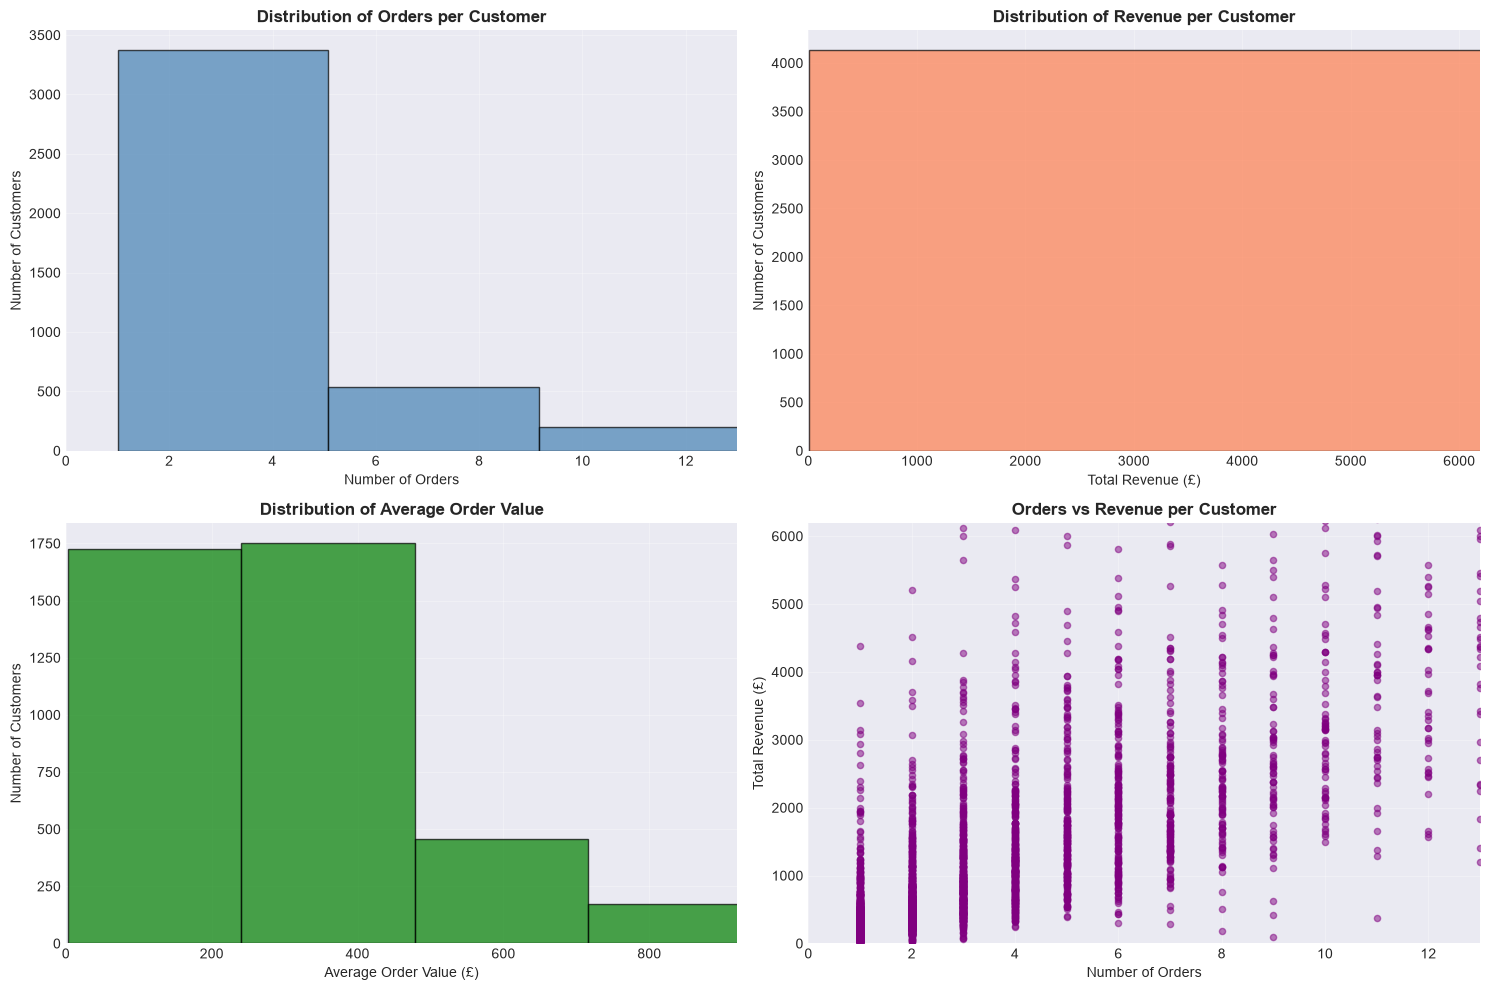

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(customer_stats['Total_Orders'], bins=50, color='steelblue', 
                edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Number of Orders')
axes[0, 0].set_ylabel('Number of Customers')
axes[0, 0].set_title('Distribution of Orders per Customer', fontweight='bold')
axes[0, 0].set_xlim(0, customer_stats['Total_Orders'].quantile(0.95))
axes[0, 0].grid(alpha=0.3)

axes[0, 1].hist(customer_stats['Total_Revenue'], bins=50, color='coral', 
                edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Total Revenue (£)')
axes[0, 1].set_ylabel('Number of Customers')
axes[0, 1].set_title('Distribution of Revenue per Customer', fontweight='bold')
axes[0, 1].set_xlim(0, customer_stats['Total_Revenue'].quantile(0.95))
axes[0, 1].grid(alpha=0.3)

axes[1, 0].hist(customer_stats['Avg_Order_Value'], bins=50, color='green', 
                edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Average Order Value (£)')
axes[1, 0].set_ylabel('Number of Customers')
axes[1, 0].set_title('Distribution of Average Order Value', fontweight='bold')
axes[1, 0].set_xlim(0, customer_stats['Avg_Order_Value'].quantile(0.95))
axes[1, 0].grid(alpha=0.3)

axes[1, 1].scatter(customer_stats['Total_Orders'], customer_stats['Total_Revenue'], 
                   alpha=0.5, s=20, color='purple')
axes[1, 1].set_xlabel('Number of Orders')
axes[1, 1].set_ylabel('Total Revenue (£)')
axes[1, 1].set_title('Orders vs Revenue per Customer', fontweight='bold')
axes[1, 1].set_xlim(0, customer_stats['Total_Orders'].quantile(0.95))
axes[1, 1].set_ylim(0, customer_stats['Total_Revenue'].quantile(0.95))
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/eda_customer_behavior.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
top_customers = customer_stats.nlargest(10, 'Total_Revenue')[['Customer ID', 'Total_Revenue', 'Total_Orders', 'Avg_Order_Value']]

print("Top 10 Customers by Revenue:\n")
top_customers

Top 10 Customers by Revenue:



,Customer ID,Total_Revenue,Total_Orders,Avg_Order_Value
4183,18102.00,349164.35,89,3923.19
1637,14646.00,248396.50,78,3184.57
1269,14156.00,196549.74,102,1926.96
1840,14911.00,152121.22,205,742.05
939,13694.00,131443.19,94,1398.33
3744,17511.00,84541.17,31,2727.13
1951,15061.00,83284.38,86,968.42
3128,16684.00,80489.21,27,2981.08
3177,16754.00,65500.07,29,2258.62
4065,17949.00,60117.60,74,812.40


In [13]:
product_stats = df.groupby('StockCode').agg({
    'Description': 'first',
    'Quantity': 'sum',
    'Revenue': 'sum',
    'Invoice': 'nunique'
}).reset_index()

product_stats.columns = ['StockCode', 'Description', 'Total_Quantity', 'Total_Revenue', 'Times_Purchased']
product_stats = product_stats.sort_values('Total_Revenue', ascending=False)

print(f"Total Products: {len(product_stats):,}\n")
print("Top 10 Products by Revenue:\n")
product_stats.head(10)

Total Products: 4,017

Top 10 Products by Revenue:



,StockCode,Description,Total_Quantity,Total_Revenue,Times_Purchased
3481,85123A,WHITE HANGING HEART T-LIGHT HOLDER,56814,151339.16,3021
1605,22423,REGENCY CAKESTAND 3 TIER,12484,143727.60,1687
4011,M,Manual,2568,98531.99,382
3459,85099B,JUMBO BAG RED WHITE SPOTTY,48731,85257.45,1708
3220,84879,ASSORTED COLOUR BIRD ORNAMENT,44431,70291.03,1333
4013,POST,POSTAGE,2212,48741.08,738
1124,21843,RETRO SPOT CAKE STAND,4056,41457.64,895
2505,48138,DOOR MAT UNION FLAG,6342,41223.56,1016
2865,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,21579,40156.05,244
1295,22086,PAPER CHAIN KIT 50'S CHRISTMAS,13839,36871.55,796


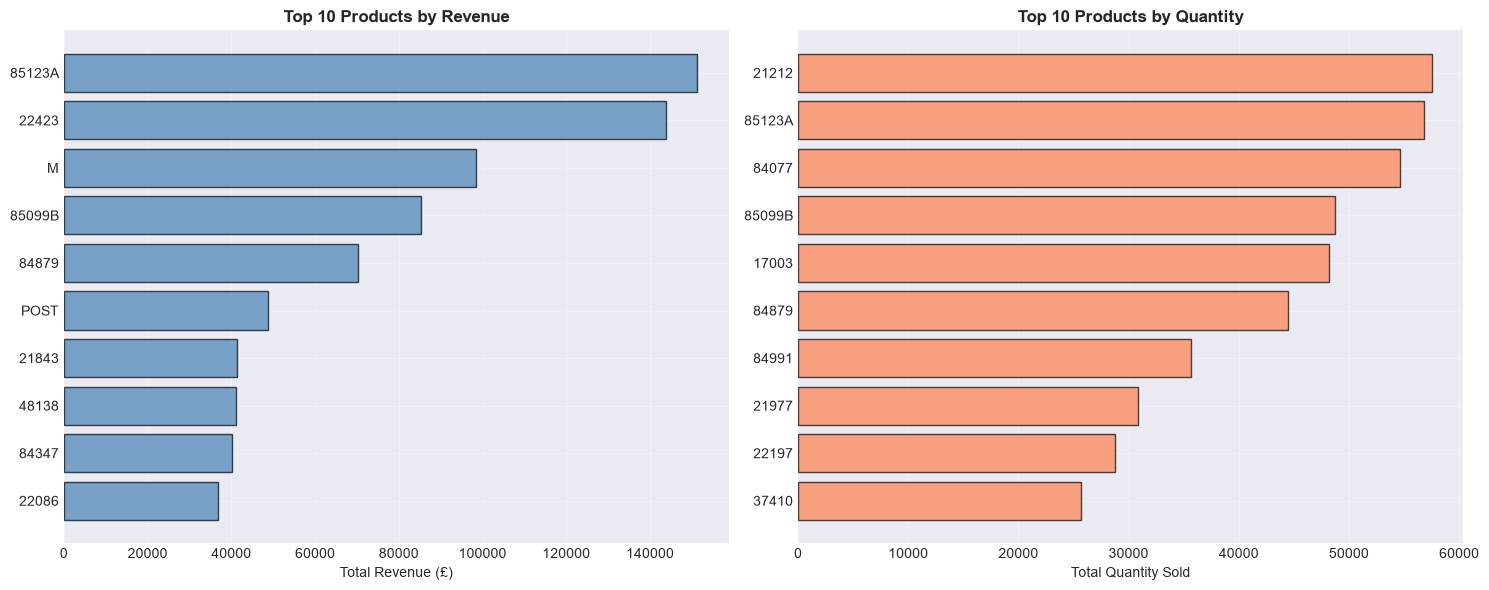

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_products_revenue = product_stats.head(10)
axes[0].barh(range(len(top_products_revenue)), top_products_revenue['Total_Revenue'], 
             color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_yticks(range(len(top_products_revenue)))
axes[0].set_yticklabels(top_products_revenue['StockCode'])
axes[0].set_xlabel('Total Revenue (£)')
axes[0].set_title('Top 10 Products by Revenue', fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(alpha=0.3)

top_products_quantity = product_stats.nlargest(10, 'Total_Quantity')
axes[1].barh(range(len(top_products_quantity)), top_products_quantity['Total_Quantity'], 
             color='coral', edgecolor='black', alpha=0.7)
axes[1].set_yticks(range(len(top_products_quantity)))
axes[1].set_yticklabels(top_products_quantity['StockCode'])
axes[1].set_xlabel('Total Quantity Sold')
axes[1].set_title('Top 10 Products by Quantity', fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/eda_top_products.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
country_stats = df.groupby('Country').agg({
    'Revenue': 'sum',
    'Invoice': 'nunique',
    'Customer ID': 'nunique'
}).reset_index()

country_stats.columns = ['Country', 'Total_Revenue', 'Total_Orders', 'Total_Customers']
country_stats = country_stats.sort_values('Total_Revenue', ascending=False)

print(f"Total Countries: {len(country_stats)}\n")
print("Top 10 Countries by Revenue:\n")
country_stats.head(10)

Total Countries: 37

Top 10 Countries by Revenue:



,Country,Total_Revenue,Total_Orders,Total_Customers
34,United Kingdom,7381644.43,17612,3969
9,EIRE,356041.86,316,5
21,Netherlands,268784.35,135,22
12,Germany,202025.39,347,67
11,France,146107.07,236,47
29,Sweden,53147.99,68,16
8,Denmark,50906.85,26,9
28,Spain,47568.65,66,25
30,Switzerland,43921.39,40,14
0,Australia,31446.80,40,15


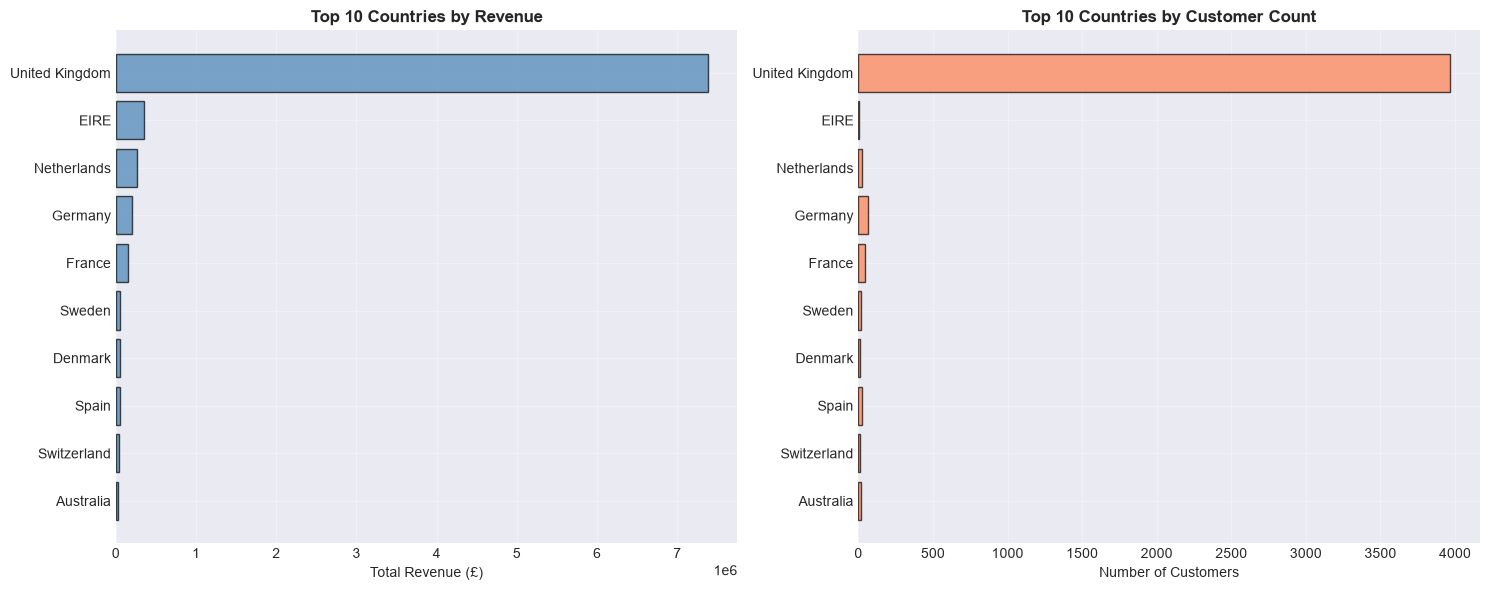

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_countries = country_stats.head(10)
axes[0].barh(range(len(top_countries)), top_countries['Total_Revenue'], 
             color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_yticks(range(len(top_countries)))
axes[0].set_yticklabels(top_countries['Country'])
axes[0].set_xlabel('Total Revenue (£)')
axes[0].set_title('Top 10 Countries by Revenue', fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(alpha=0.3)

axes[1].barh(range(len(top_countries)), top_countries['Total_Customers'], 
             color='coral', edgecolor='black', alpha=0.7)
axes[1].set_yticks(range(len(top_countries)))
axes[1].set_yticklabels(top_countries['Country'])
axes[1].set_xlabel('Number of Customers')
axes[1].set_title('Top 10 Countries by Customer Count', fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/eda_geographic_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
uk_revenue = country_stats[country_stats['Country'] == 'United Kingdom']['Total_Revenue'].values[0]
total_revenue = country_stats['Total_Revenue'].sum()
uk_percentage = (uk_revenue / total_revenue) * 100

print(f"UK Revenue: £{uk_revenue:,.2f}")
print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"UK represents {uk_percentage:.2f}% of total revenue")

UK Revenue: £7,381,644.43
Total Revenue: £8,798,233.74
UK represents 83.90% of total revenue


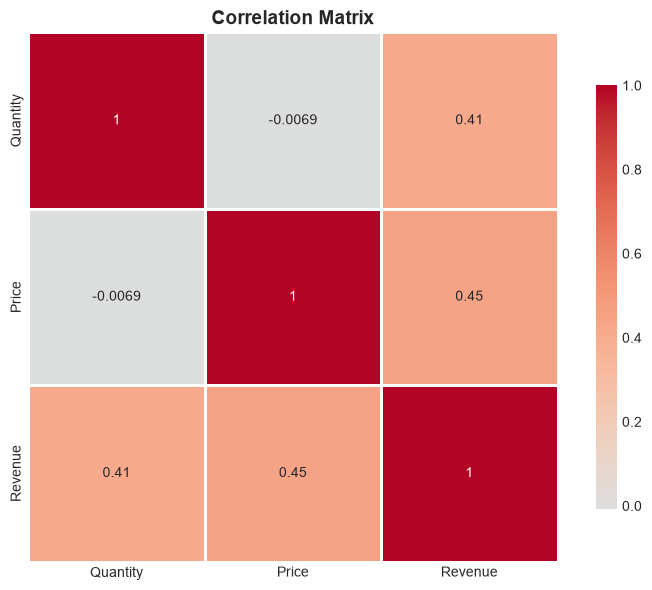


Correlation Insights:
Quantity vs Price: -0.007
Quantity vs Revenue: 0.414
Price vs Revenue: 0.452


In [18]:
numeric_cols = ['Quantity', 'Price', 'Revenue']
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/eda_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCorrelation Insights:")
print(f"Quantity vs Price: {correlation_matrix.loc['Quantity', 'Price']:.3f}")
print(f"Quantity vs Revenue: {correlation_matrix.loc['Quantity', 'Revenue']:.3f}")
print(f"Price vs Revenue: {correlation_matrix.loc['Price', 'Revenue']:.3f}")


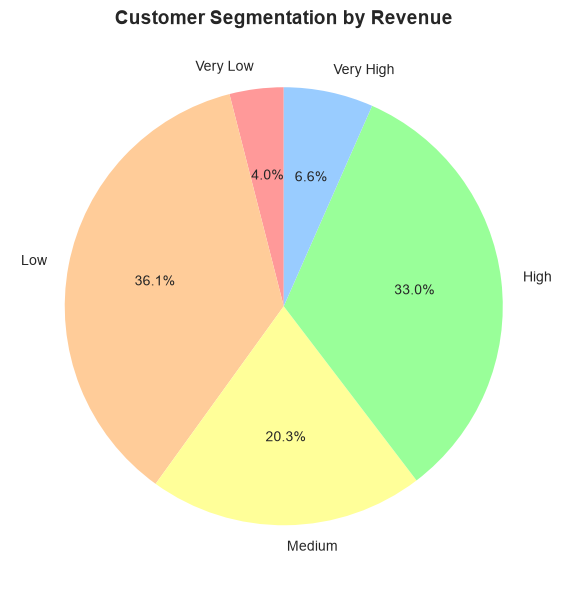


Customer Distribution by Revenue:
Very Low: 172 customers (4.0%)
Low: 1,555 customers (36.1%)
Medium: 876 customers (20.3%)
High: 1,424 customers (33.0%)
Very High: 285 customers (6.6%)


In [19]:
customer_segments = pd.cut(customer_stats['Total_Revenue'], 
                          bins=[0, 100, 500, 1000, 5000, float('inf')],
                          labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

segment_counts = customer_segments.value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=['#ff9999','#ffcc99','#ffff99','#99ff99','#99ccff'])
plt.title('Customer Segmentation by Revenue', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/eda_customer_segments.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCustomer Distribution by Revenue:")
for segment, count in segment_counts.items():
    print(f"{segment}: {count:,} customers ({count/len(customer_stats)*100:.1f}%)")


In [20]:
eda_summary = {
    'analysis_date': pd.Timestamp.now().isoformat(),
    'dataset': {
        'total_transactions': int(len(df)),
        'total_customers': int(df['Customer ID'].nunique()),
        'total_products': int(df['StockCode'].nunique()),
        'total_countries': int(df['Country'].nunique()),
        'date_range_days': int((df['InvoiceDate'].max() - df['InvoiceDate'].min()).days)
    },
    'revenue': {
        'total': float(df['Revenue'].sum()),
        'mean': float(df['Revenue'].mean()),
        'median': float(df['Revenue'].median()),
        'std': float(df['Revenue'].std())
    },
    'customer_insights': {
        'avg_orders_per_customer': float(customer_stats['Total_Orders'].mean()),
        'avg_revenue_per_customer': float(customer_stats['Total_Revenue'].mean()),
        'avg_order_value': float(customer_stats['Avg_Order_Value'].mean()),
        'top_customer_revenue': float(customer_stats['Total_Revenue'].max())
    },
    'geographic': {
        'uk_revenue_percentage': float(uk_percentage),
        'top_country': country_stats.iloc[0]['Country'],
        'top_country_revenue': float(country_stats.iloc[0]['Total_Revenue'])
    },
    'temporal': {
        'peak_month': str(monthly_revenue.loc[monthly_revenue['Total_Revenue'].idxmax(), 'YearMonth']),
        'peak_month_revenue': float(monthly_revenue['Total_Revenue'].max())
    }
}

import json
with open('../reports/eda_summary.json', 'w') as f:
    json.dump(eda_summary, f, indent=4)

print("EDA summary saved to reports/eda_summary.json")


EDA summary saved to reports/eda_summary.json


In [21]:
print("Key Insights from EDA:\n")

print(f"1. REVENUE ANALYSIS")
print(f"   - Total Revenue: £{df['Revenue'].sum():,.2f}")
print(f"   - Average Transaction: £{df['Revenue'].mean():.2f}")
print(f"   - Peak Month: {monthly_revenue.loc[monthly_revenue['Total_Revenue'].idxmax(), 'YearMonth']}")

print(f"\n2. CUSTOMER BEHAVIOR")
print(f"   - Total Customers: {df['Customer ID'].nunique():,}")
print(f"   - Avg Orders/Customer: {customer_stats['Total_Orders'].mean():.1f}")
print(f"   - Avg Revenue/Customer: £{customer_stats['Total_Revenue'].mean():.2f}")

print(f"\n3. GEOGRAPHIC INSIGHTS")
print(f"   - UK dominates with {uk_percentage:.1f}% of revenue")
print(f"   - Operating in {df['Country'].nunique()} countries")

print(f"\n4. PRODUCT INSIGHTS")
print(f"   - Total Products: {df['StockCode'].nunique():,}")
print(f"   - Top Product Revenue: £{product_stats.iloc[0]['Total_Revenue']:,.2f}")

print(f"\n5. TEMPORAL PATTERNS")
print(f"   - Data spans {(df['InvoiceDate'].max() - df['InvoiceDate'].min()).days} days")
print(f"   - Peak revenue in {monthly_revenue.loc[monthly_revenue['Total_Revenue'].idxmax(), 'YearMonth']}")

print("\nEDA complete - ready for RFM analysis and clustering")


Key Insights from EDA:

1. REVENUE ANALYSIS
   - Total Revenue: £8,798,233.74
   - Average Transaction: £21.95
   - Peak Month: 2010-11

2. CUSTOMER BEHAVIOR
   - Total Customers: 4,312
   - Avg Orders/Customer: 4.5
   - Avg Revenue/Customer: £2040.41

3. GEOGRAPHIC INSIGHTS
   - UK dominates with 83.9% of revenue
   - Operating in 37 countries

4. PRODUCT INSIGHTS
   - Total Products: 4,017
   - Top Product Revenue: £151,339.16

5. TEMPORAL PATTERNS
   - Data spans 373 days
   - Peak revenue in 2010-11

EDA complete - ready for RFM analysis and clustering
